In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic
from waymo_agent.graph_env.ENV import RideShareEnv
from waymo_agent.models.ppo_model import *

In [6]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *
from waymo_agent.models.train_utils import *

In [7]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [8]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

In [9]:
env_cfg = EnvConfig(
    max_episode_steps=60 * 8,
    vehicle_per_node=0.8,
    lambda_per_node=0.01,
    max_pending_requests=100,
    max_new_requests_per_step=20,
)
plt_cfg = PlotConfig()
env_model = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 7.8200 (target: 7.8200)


In [10]:
GAMMA = get_gamma_from_half_life(env_cfg.max_episode_steps // 2)
round(GAMMA, 5)

0.99712

# Run Sim

In [11]:
def discounted_rewards(rewards: np.ndarray, gamma: float = 0.997) -> np.ndarray:
    """
    Discount rewards using discount factor gamma.
    """
    disc_schedule = exp_decay_half_life(len(rewards), gamma=gamma)
    return rewards * disc_schedule


def get_act_dict(agents: tuple[PricingAgent, DispatchAgent, RepositionAgent], obs: ObservationDict) -> ActionDict:
    price_agent, dispatch_agent, reposition_agent = agents
    prices = price_agent.price(obs)
    dispatch_actions = dispatch_agent.dispatch(obs)
    reposition_actions = reposition_agent.reposition(obs)

    action_agent: ActionDict = {
        "prices": prices,
        "dispatch": dispatch_actions,
        "reposition": reposition_actions,
    }
    return action_agent

In [12]:
@torch.no_grad()
def run_model_simulation(
    env_curr: RideShareEnv,
    model: RideShareActorCritic,
    num_iter: int = 1,
    gamma: float = GAMMA,
    deterministic: bool = False,
):
    """
    Returns:
      REWARDS: list[episode][t] discounted reward_t
      OBS:     list[episode][t] obs dict (numpy)
      ACT:     list[episode][t] action dict (numpy)
    """
    model.eval()

    REWARDS: list[np.ndarray] = []
    OBS: list[list[dict[str, np.ndarray]]] = []
    ACT: list[list[dict[str, np.ndarray]]] = []
    TERMINATED: list[bool] = []
    TRUNCATED: list[bool] = []

    for i in tqdm(range(num_iter), desc="model rollout"):
        # tqdm.write(f"Starting episode {i+1}/{num_iter}...")
        obs_np, _info = env_curr.reset()
        terminated = False
        truncated = False
        done = False

        rews_raw: list[float] = []
        obs_list: list[dict[str, np.ndarray]] = []
        act_list: list[dict[str, np.ndarray]] = []

        while not done:
            # tqdm.write(f"Step {env_curr.current_step}/{env_curr.config.max_episode_steps}")
            obs_list.append(obs_np)

            obs_t = obs_pd_to_torch(obs_np)

            act_t = model.act(obs_t, deterministic=deterministic)
            act_np = action_torch_to_numpy(act_t)
            env_curr._validate_action(act_np)
            act_list.append(act_np)

            obs_np, reward, terminated, truncated, _info = env_curr.step(act_np)  # type: ignore[arg-type]
            # print(f"Reward: {reward}")
            rews_raw.append(float(reward))
            done = bool(terminated) or bool(truncated)

        rews = discounted_rewards(np.array(rews_raw, dtype=np.float32), gamma=gamma)
        REWARDS.append(rews)
        OBS.append(obs_list)
        ACT.append(act_list)
        TERMINATED.append(terminated)
        TRUNCATED.append(truncated)

    return REWARDS, OBS, ACT, TERMINATED, TRUNCATED

In [13]:
model_cfg = ActorCriticConfig(hidden_size=256)
model = RideShareActorCritic(env_model, model_cfg)
cfg_ppo = PPOTrainConfig(total_steps=500, eval_every_updates=1, eval_episodes=2, debug=True)

In [14]:
REWARDS, OBS, ACT, TERMINATED, TRUNCATED = run_model_simulation(env_model, model, num_iter=1)

model rollout:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
TERMINATED, TRUNCATED

([False], [True])

In [16]:
env_model._rewards

{'penalty_multiple_dispatch_assignment': 0.4,
 'penalty_assign_to_unavailable_vehicle': 0.8,
 'distance_penalty_xy_normed': 0.0,
 'penalty_rejected': np.float64(-0.0),
 'penalty_expire': np.float64(-0.0),
 'ride_reward_total': np.float64(-13.064067162573338)}

In [17]:
# import importlib
# import waymo_agent.data_classes.enriched_df_base

# _ = importlib.reload(waymo_agent.data_classes.enriched_df_base)

# Train PPO

In [18]:
model = RideShareActorCritic(env_model, model_cfg)
cfg_ppo = PPOTrainConfig(total_steps=20_000, gamma=GAMMA, log_every_updates=1)

In [19]:
pprint(cfg_ppo)

PPOTrainConfig(total_steps=20000,
               debug=False,
               gamma=0.9971160533345892,
               gae_lambda=0.95,
               lr=0.0003,
               clip_eps=0.2,
               vf_coef=0.5,
               ent_coef=0.01,
               max_grad_norm=0.5,
               update_epochs=4,
               minibatch_size=256,
               deterministic_eval=True,
               log_every_updates=1,
               eval_episodes=2,
               eval_every_updates=5,
               patience=20,
               min_delta=0.001,
               save_best=True)


In [20]:
pprint(env_cfg)

EnvConfig(map_name='manhattan-sparse-782-nodes-enriched.graphml',
          map_dir=PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps'),
          vehicle_per_node=0.8,
          max_vehicles=50,
          time_step_delta=datetime.timedelta(seconds=60),
          max_episode_steps=480,
          day_per_week=7,
          hours_per_day=24,
          lambda_per_node=0.01,
          lambda_variation_coef=2.0,
          max_new_requests_per_step=20,
          max_pending_requests=100,
          max_wait_time_minutes=15,
          max_price=inf,
          invalid_id=-1,
          acceptance_margin_weight=-2.0,
          acceptance_supply_demand_weight=3.0,
          battery_consumption_per_km=0.01,
          charge_rate_per_minute=0.12,
          min_battery_for_assignment=0.2,
          chargable_node_ratio=0.01,
          max_chargers_per_node=1,
          penalty_rejected=-0.01,
          penalty_expire=-0.5,
          penalty_overflow=0,
          reward_frac_ride_completion=15

In [21]:
obs, _ = env_model.reset()

In [22]:
veh, req, rides = get_obs_tuple(env_model)

In [23]:
dtt([veh, req, rides], how="head")

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 int64 
 float32 
 float32 
 float32 
 int64 
 int64 
 
 
 
 
 0 
 0 
 -0.321 
 -0.737 
 0.712 
 0 
 -1 
 
 
 1 
 1 
 -0.177 
 -0.483 
 0.948 
 0 
 -1 
 
 
 2 
 2 
 -0.363 
 -0.416 
 0.634 
 0 
 -1 
 
 
 3 
 3 
 0.555 
 0.395 
 0.765 
 0 
 -1 
 
 
 4 
 4 
 0.237 
 0.063 
 0.843 
 0 
 -1 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 int64 
 datetime64[ns] 
 int64 
 float64 
 float64 
 float64 
 float64 
 timedelta64[ns] 
 timedelta64[ns] 
 int64 
 int64 
 float64 
 float64 
 int64 
 float64 
 float64 
 object 
 int64 
 int64 
 float64 
 float64 
 
 
 
 
 0 
 3771 
 2025-01-06 07:20:17.522798 
 10525 
 -0.801 
 1.885 
 5.355 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 371188756 
 0.367 
 0.092 
 9166033062 
 -0.104 
 -0.512 
 [371188756, 371188750, 13238997597, 589099734, 42445392, 42445390, 42445417, 42448707, 42440743, 42439006, 9166033062] 
 371188756 
 371188750 
 0.0 
 5355.445 
 
 
 1 
 3770 
 2025-01-06 07:20:17.522798 
 30898 
 -0.268 
 1.782 
 7.917 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 278608816 
 -0.308 
 -0.727 
 2348991703 
 -0.242 
 0.225 
 [278608816, 587988061, 3884569931, 42437749, 588455743, 588455742, 1773066054, 541467364, 5161246307, 42440804, 42427316, 5706569898, 42428433, 42440829, 4143859873, 3788379733, 42440838, 4142105813, 3788364714, 12417264049, 42440854, 9607729579, 246649429, 11027819091, 42445769, 246579597, 12161232243, 42427494, 42437699, 42437678, 7073877295, 6575692624, 247081705, 42437379, 42453555, 593854257, 11017187935, 12153915859, 2348991703] 
 278608816 
 587988061 
 0.0 
 7917.161 
 
 
 2 
 3769 
 2025-01-06 07:20:17.522798 
 28748 
 -2.478 
 1.652 
 1.873 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42450460 
 0.499 
 0.593 
 42446036 
 0.318 
 0.394 
 [42450460, 7076060068, 42457660, 42429330, 596776164, 42429324, 42446036] 
 42450460 
 7076060068 
 0.0 
 1872.797 
 
 
 3 
 3768 
 2025-01-06 07:20:17.522798 
 1292 
 -2.213 
 1.509 
 3.789 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42430722 
 -0.213 
 0.200 
 42442918 
 0.080 
 -0.130 
 [42430722, 42449550, 1815133244, 42435705, 42440012, 42430367, 42430358, 42440153, 42445928, 596775870, 596775867, 42438886, 100522741, 42434085, 42444049, 42444051, 42442947, 42442937, 42442918] 
 42430722 
 42449550 
 0.0 
 3788.761 
 
 
 4 
 3767 
 2025-01-06 07:20:17.522798 
 49016 
 -6.077 
 1.755 
 8.776 
 NaN 
 0 days 00:15:00 
 0 days 
 0 
 42430304 
 -0.127 
 -0.081 
 42425681 
 0.790 
 0.694 
 [42430304, 42437644, 42452973, 42443950, 42437358, 42445916, 42444043, 42434074, 596775840, 596775867, 596775870, 596775900, 42436703, 42436705, 42446998, 42449963, 42448379, 6680686985, 42432861, 42423564, 2711029280, 42448326, 6177439749, 42436531, 42436492, 42456060, 42429342, 4779073679, 4779073677, 42424025, 371209940, 371239958, 42425681] 
 42430304 
 42437644 
 0.0 
 8776.113 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 int64 
 int64 
 int64 
 float32 
 float32 
 int64 
 float32 
 float32 
 float32 
 float32 
 float32 
 float32 
 float32 
 object 
 int64 
 int64 
 float32 
 bool 
 
 
 
 
 0 
 -1 
 0 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 1 
 -1 
 1 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 2 
 -1 
 2 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 

In [24]:
model_name = f"ppo_model_V-{env_model.config.vehicle_per_node:.2f}_L-{env_model.config.lambda_per_node:.2f}_H-{model.model_cfg.hidden_size}_NV-{env_model.num_vehicles}_MR-{env_model.config.max_pending_requests}"
model_name

'ppo_model_V-0.80_L-0.01_H-256_NV-50_MR-100'

In [25]:
from waymo_agent.models.train_ppo import train_ppo


model, logs = train_ppo(env_model, model, train_cfg=cfg_ppo, save_path=MODEL_WEIGHT_DIR / f"{model_name}.pt")

PPO steps:   0%|          | 0/20000 [00:00<?, ?step/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

...

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# summary =

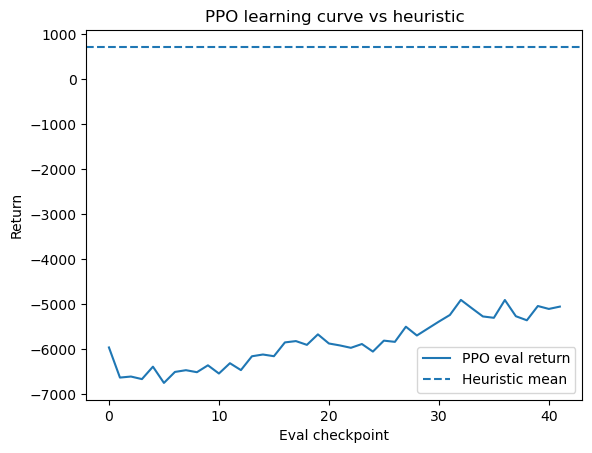

In [26]:
plot_learning_curve_vs_baseline(logs, heur_mean=env_cfg.max_episode_steps * 1.5)

In [ ]:
from waymo_agent.models.train_ppo import train_ppo


model, logs = train_ppo(env_model, model, train_cfg=cfg_ppo, save_path=MODEL_WEIGHT_DIR / f"{model_name}.pt")

PPO steps:   0%|          | 0/20000 [00:00<?, ?step/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

...

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

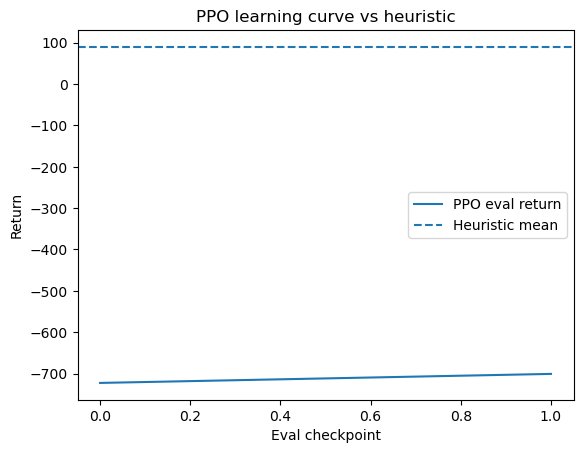

In [ ]:
plot_learning_curve_vs_baseline(logs, heur_mean=env_cfg.max_episode_steps * 1.5)